In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [3]:
splitting_data = pd.read_csv(splitting_file)

In [4]:
# os.mkdir('./Plots')

In [5]:
import scipy.stats

# Drop any NaN values from 'fast'
fast_axial = splitting_data['fast'].dropna().values

# For axial data (e.g., -90° to 90°, where θ and θ+180° are equivalent), double angles for mean and std calculation
angles_rad = np.deg2rad(fast_axial)
doubled_angles = 2 * angles_rad

# Compute mean direction in doubled space
mean_dir_doubled = np.arctan2(np.sum(np.sin(doubled_angles)), np.sum(np.cos(doubled_angles)))

# Convert back to original space (divide by 2) and to degrees
mean_axial_rad = 0.5 * mean_dir_doubled
mean_axial_deg = np.rad2deg(mean_axial_rad)

# Ensure result is within -90° to 90°
if mean_axial_deg > 90:
    mean_axial_deg -= 180
elif mean_axial_deg < -90:
    mean_axial_deg += 180

# Calculate the length of the mean resultant vector in doubled-angle space
R = np.hypot(np.sum(np.cos(doubled_angles)), np.sum(np.sin(doubled_angles))) / len(doubled_angles)

# Standard deviation for circular (axial) data (see Batschelet 1981, or scipy.stats.circstd note)
# Circular standard deviation in radians:
# std = sqrt(-2 * ln(R)) / 2 because of doubled angles for axial data
if R < 1e-8:  # degenerate/dispersed case
    std_axial_rad = np.pi / 2
else:
    std_axial_rad = np.sqrt(-2 * np.log(R)) / 2

std_axial_deg = np.rad2deg(std_axial_rad)

print("Mean axial 'fast' direction (degrees):", mean_axial_deg)
print("Axial 'fast' direction standard deviation (degrees):", std_axial_deg)


Mean axial 'fast' direction (degrees): 25.034622520537823
Axial 'fast' direction standard deviation (degrees): 37.46861352714852


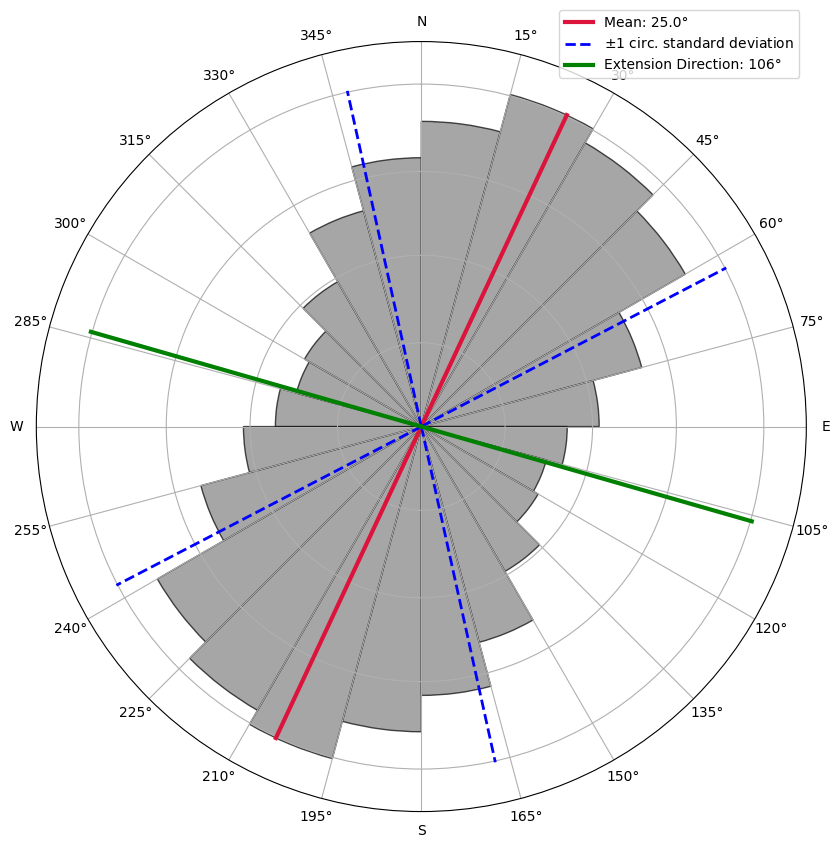

In [ ]:
# Rose plot for 'fast' directions, with mean/circular std and reference lines at 106°/286°.
import matplotlib.pyplot as plt
import numpy as np

fast_angles = splitting_data['fast'].dropna().values

# Restrict to valid range
fast_angles = fast_angles[(fast_angles >= -90) & (fast_angles <= 90)]

# Symmetrize for axial (180-degree) ambiguity
all_angles_deg = np.concatenate([fast_angles, fast_angles + 180])
all_angles_mod360 = np.mod(all_angles_deg, 360)
all_angles_rad = np.deg2rad(all_angles_mod360)

# Bin edges for rose plot
num_bins = 24
bin_edges_deg = np.linspace(0, 360, num_bins + 1)
bin_edges_rad = np.deg2rad(bin_edges_deg)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

# Rose histogram (sqrt counts)
counts, bins = np.histogram(all_angles_rad, bins=bin_edges_rad)
counts = np.sqrt(counts)
bars = ax.bar(bin_edges_rad[:-1], counts, width=np.diff(bin_edges_rad), align='edge', edgecolor='k', alpha=0.7, color='grey')

# 0° = North, increase clockwise (seismo convention)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Set xticks for every 15°; label only N/E/S/W, but ticks for all
all_xtick_degs = np.arange(0, 360, 15)
all_xtick_rads = np.deg2rad(all_xtick_degs)
ax.set_xticks(all_xtick_rads)
cardinal_locs_deg = [0, 90, 180, 270]
cardinal_labels = ['N', 'E', 'S', 'W']
xtick_labels = []
for deg in all_xtick_degs:
    if deg in cardinal_locs_deg:
        xtick_labels.append(cardinal_labels[cardinal_locs_deg.index(deg)])
    else:
        xtick_labels.append(f"{deg}°")
ax.set_xticklabels(xtick_labels)

max_count = counts.max()
yticks = np.linspace(0, max_count, num=5, dtype=int)
ax.set_yticks(yticks)
ax.set_yticklabels([])

# -- Show mean and circular std as lines --
mean_axial_deg_plot = np.mod(mean_axial_deg, 180)  # 180 symmetry for axial data
theta_mean = np.deg2rad(mean_axial_deg_plot)
theta_mean_opposite = theta_mean + np.pi

# Calculate ±1 std directions
theta_std_plus = theta_mean + std_axial_rad
theta_std_minus = theta_mean - std_axial_rad
theta_std_plus_opposite = theta_mean_opposite + std_axial_rad
theta_std_minus_opposite = theta_mean_opposite - std_axial_rad

# Plot mean directions (two lines 180° apart)
ax.plot([theta_mean, theta_mean], [0, max_count], color='crimson', lw=3, label=f"Mean: {mean_axial_deg_plot:.1f}°")
ax.plot([theta_mean_opposite, theta_mean_opposite], [0, max_count], color='crimson', lw=3)

# -- Plot arcs from each std dev minus to plus --
arc_res = 300  # number of points for smoothness


# Optionally overlay the lines at ±1 std for completeness (shown, but can be removed if only arcs desired)
ax.plot([theta_std_plus, theta_std_plus], [0, max_count], color='blue', ls='--', lw=2, label=r'$\pm$1 circ. standard deviation')
ax.plot([theta_std_minus, theta_std_minus], [0, max_count], color='blue', ls='--', lw=2)
ax.plot([theta_std_plus_opposite, theta_std_plus_opposite], [0, max_count], color='blue', ls='--', lw=2)
ax.plot([theta_std_minus_opposite, theta_std_minus_opposite], [0, max_count], color='blue', ls='--', lw=2)

# --- Add line at 106° and 106°+180° ---
line106_rad = np.deg2rad(106)
line286_rad = np.deg2rad((106 + 180) % 360)
ax.plot([line106_rad, line106_rad], [0, max_count], color='green', lw=3, label='Extension Direction: 106°')
ax.plot([line286_rad, line286_rad], [0, max_count], color='green', lw=3)

# --- Add margin (outer) radial ticks for xticks, with labels along the outside of the circle ---
r_outer = max_count * 1.03  # a bit beyond the data
tick_length = max_count * 0.07  # length of tick

ax.set_ylim(0, r_outer + 0.09*max_count)

# Optionally add a legend
ax.legend(loc="upper right", bbox_to_anchor=(1, 1.05))

# plt.show()

plt.savefig('./Plots/Figure_5.png', dpi=150, bbox_inches='tight')